In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from scipy.stats import pearsonr
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load Dataset
cr = pd.read_csv("Crime Economics - data.csv")

# Show first 5 rows
cr.head()

,Country,Crime Rate,Unemployment (%),HDI,Population Density (per sq. km),Weapons per 100 persons,Per Capita Income,Gini Coefficient,Literacy Rate,Happiness Index
0,Afghanistan,76.31,11.2,0.51,57.00,12.5,508.00,27.8,0.38,2.52
1,Albania,42.53,11.3,0.80,100.00,12.0,"5,181.00",33.2,0.98,5.12
2,Algeria,52.03,11.5,0.75,18.00,2.1,"3,368.00",27.6,0.80,4.89
3,Argentina,63.82,7.0,0.85,16.00,7.4,"8,476.00",41.4,0.98,5.93
4,Armenia,22.79,7.7,0.78,99.00,6.1,"4,266.00",34.4,1.00,5.28


<hr></hr>

### **Data Preparation**


In [3]:
# Dataset dimension
cr.shape

(114, 10)

In [4]:
# Dataset info
cr.info()

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 10 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          114 non-null    str    
 1   Crime Rate                       114 non-null    float64
 2   Unemployment (%)                 114 non-null    float64
 3   HDI                              114 non-null    float64
 4   Population Density (per sq. km)  114 non-null    str    
 5   Weapons per 100 persons          114 non-null    float64
 6   Per Capita Income                114 non-null    str    
 7   Gini Coefficient                 114 non-null    float64
 8   Literacy Rate                    114 non-null    float64
 9   Happiness Index                  114 non-null    float64
dtypes: float64(7), str(3)
memory usage: 11.5 KB


In [5]:
# Check Data types
cr.dtypes

Country                                str
Crime Rate                         float64
Unemployment (%)                   float64
HDI                                float64
Population Density (per sq. km)        str
Weapons per 100 persons            float64
Per Capita Income                      str
Gini Coefficient                   float64
Literacy Rate                      float64
Happiness Index                    float64
dtype: object

In [6]:
# Convert to float
cr["Population Density (per sq. km)"] = cr["Population Density (per sq. km)"].str.replace(",", "",regex=False).astype("float")


In [7]:
# Conver to float
cr["Per Capita Income"] = cr["Per Capita Income"].str.replace(",","",regex=False).astype("float")

In [8]:
# Check data types again
cr.dtypes

Country                                str
Crime Rate                         float64
Unemployment (%)                   float64
HDI                                float64
Population Density (per sq. km)    float64
Weapons per 100 persons            float64
Per Capita Income                  float64
Gini Coefficient                   float64
Literacy Rate                      float64
Happiness Index                    float64
dtype: object

In [9]:
# Check null values
cr.isnull().sum()

Country                            0
Crime Rate                         0
Unemployment (%)                   0
HDI                                0
Population Density (per sq. km)    0
Weapons per 100 persons            0
Per Capita Income                  0
Gini Coefficient                   0
Literacy Rate                      0
Happiness Index                    0
dtype: int64

In [10]:
# Check for duplicated data points
cr.duplicated().sum()

np.int64(0)

In [11]:
# Rename columns
cr = cr.rename(columns={
"Crime Rate": "crime_rate", 
"HDI": "human_development_index",                        
"Unemployment (%)": "unemployment",                                            
"Population Density (per sq. km)": "population_density",
"Weapons per 100 persons": "weapons_per_100",        
"Per Capita Income": "income",        
"Gini Coefficient": "gini",               
"Literacy Rate": "literacy_rate",
"Happiness Index": "happiness_index"  
})

<hr></hr>

### **Descriptive Statistics**

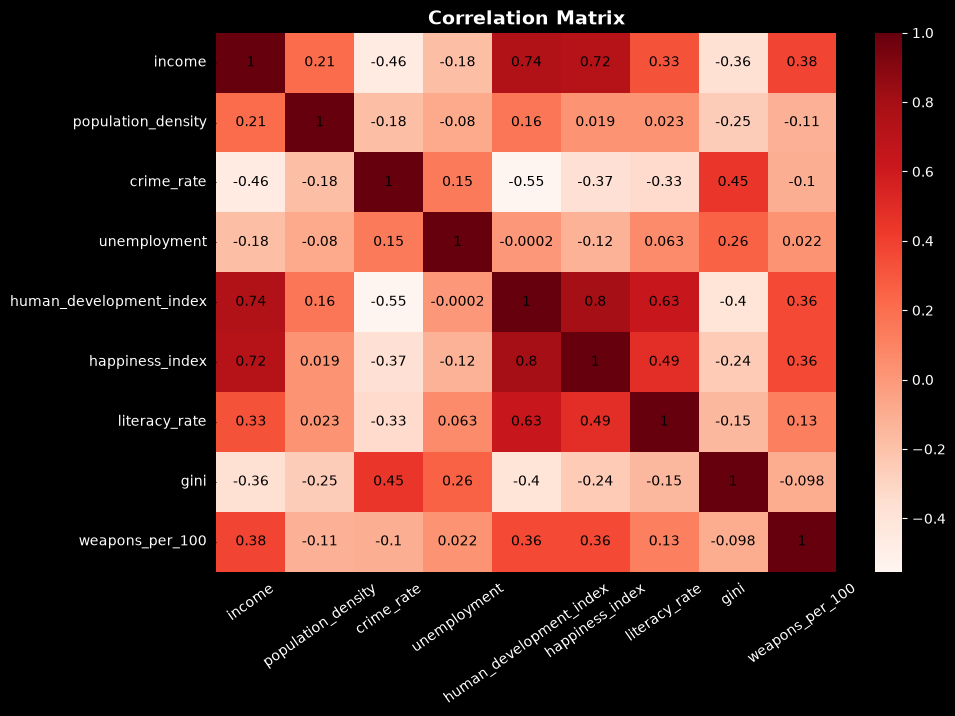

In [12]:
# Select features for correlation matrix
cm = cr[["income","population_density","crime_rate", "unemployment", "human_development_index", "happiness_index","literacy_rate", "gini","weapons_per_100"]].corr()

plt.figure(figsize=(10,7), facecolor="black")
sns.heatmap(cm, annot=True, cmap="Reds", annot_kws={"color": "black"}).collections[0].colorbar.ax.tick_params(colors="white")
plt.title("Correlation Matrix", fontweight="bold", color="white",fontsize=14)
plt.xticks(rotation=35, color="white")
plt.yticks( color="white")
plt.show()

In [36]:
# Summary statistics
num_cols = ["income","population_density","crime_rate", "unemployment", "human_development_index", "happiness_index","literacy_rate", "gini","weapons_per_100"]

print(f"Summary Statistics:")
print("========================================================================")
print(cr[num_cols].describe().round(3).T)
print("========================================================================")


Summary Statistics:
                         count       mean        std     min       25%  \
income                   114.0  17725.175  22101.148  508.00  3570.000   
population_density       114.0    283.868    985.223    2.00    43.000   
crime_rate               114.0     44.498     14.220   15.23    33.420   
unemployment             114.0      7.744      5.642    0.70     4.200   
human_development_index  114.0      0.782      0.123    0.49     0.712   
happiness_index          114.0      5.748      1.025    2.52     5.045   
literacy_rate            114.0      0.900      0.139    0.38     0.837   
gini                     114.0     37.092      9.578    0.36    31.425   
weapons_per_100          114.0     12.350     14.309    0.00     2.850   

                              50%        75%        max  
income                   7447.000  23057.250  117182.00  
population_density         89.000    155.750    8041.00  
crime_rate                 44.715     54.212      83.76  
unemplo

In [48]:
# Descriptive statistics for skewness
desc = cr[num_cols].describe().T
desc["skewness"] = cr[num_cols].skew()

print("Variables Skewness:")
print("===========================================")
print(desc["skewness"])


Variables Skewness:
income                     1.905017
population_density         6.895084
crime_rate                 0.257049
unemployment               2.075813
human_development_index   -0.479001
happiness_index           -0.322020
literacy_rate             -1.886311
gini                       0.572111
weapons_per_100            4.147184
Name: skewness, dtype: float64


#### Notable Skewness
1. Population Density (skewness of 6.90): This is the most skewed variable in the dataset. It might be because of how population density varies significantly across countries, with a small number of nations showing exceptionally high density levels, hence creating a highly right-skewed distribution.


2. Weapons per 100 Persons (skewness of 4.15): Most countries have low weapon ownership, while a few countries (especially the U.S.) are extreme outliers.


3. Unemployment (2.08) and Per Capita Income (1.91): This suggest a few countries experience high unemployment or income levels in this dataset

<hr></hr>

### **Exploratory Analysis**

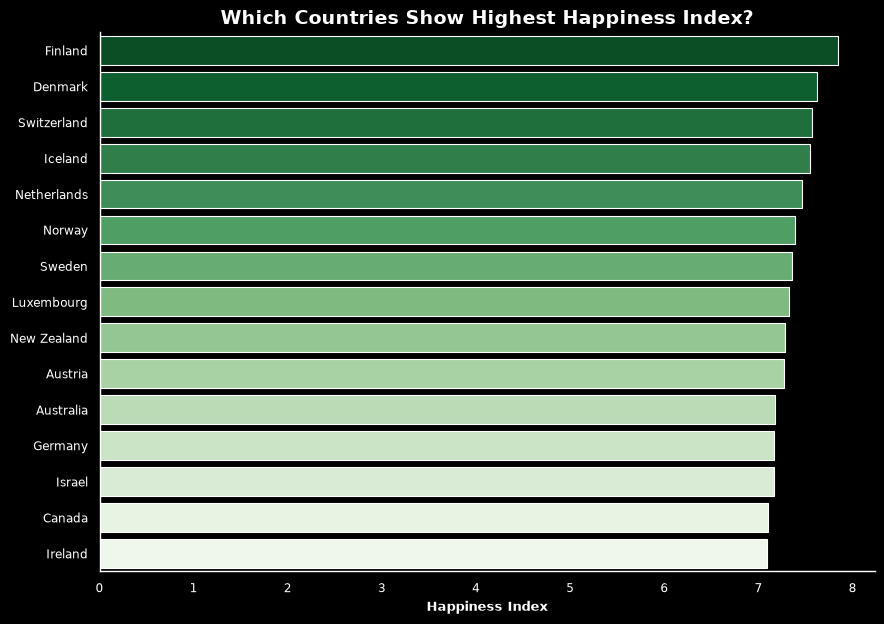

In [46]:
# Group happiness index by country
happiness_country = cr.groupby("Country")["happiness_index"].mean().sort_values(ascending=False).head(15).reset_index()

# Plot average Happiness Index by country
plt.figure(figsize=(10,7), facecolor="black")
ax = plt.gca()
ax.set_facecolor("black")
sns.set_context("paper")
sns.barplot(happiness_country, x="happiness_index", y="Country", palette="Greens_r", edgecolor="white")
plt.title("Which Countries Show Highest Happiness Index?", fontweight="bold", color="white", fontsize=14)
plt.ylabel("")
plt.xlabel("Happiness Index", color="white", fontweight="bold")
plt.xticks(color="white")
plt.yticks(color="white")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("white")
ax.spines["bottom"].set_color("white")
plt.show()

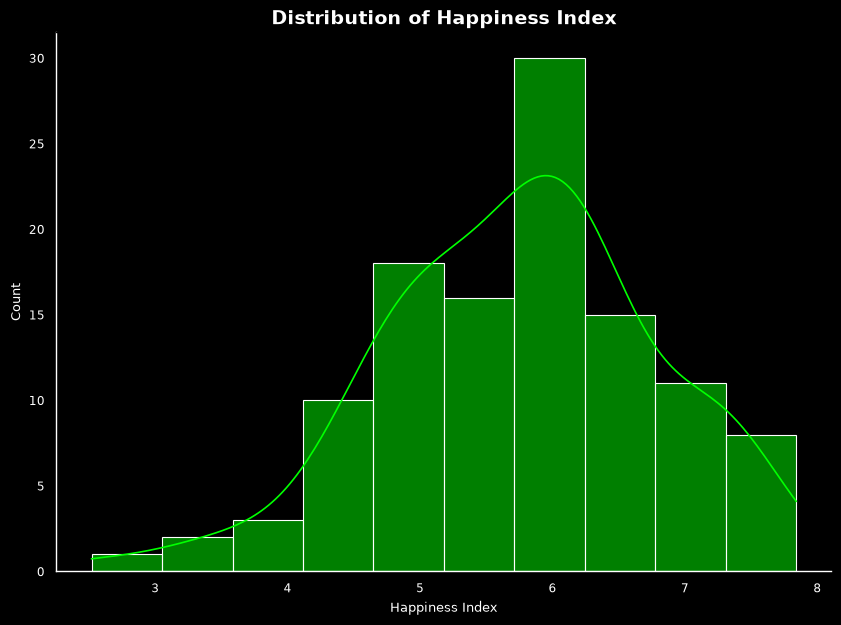

In [16]:
# Happiness Index histogram
plt.figure(figsize=(10,7),facecolor="black")
plt.gca().set_facecolor("black")
sns.histplot(cr["happiness_index"], kde=True, color="lime", edgecolor="white")

plt.title("Distribution of Happiness Index", fontweight="bold", color="white", fontsize=14)
plt.xlabel("Happiness Index", color="white")
plt.ylabel("Count", color="white")


plt.xticks(color="white")
plt.yticks(color="white")

plt.gca().spines["left"].set_color("white")
plt.gca().spines["bottom"].set_color("white")


plt.show()


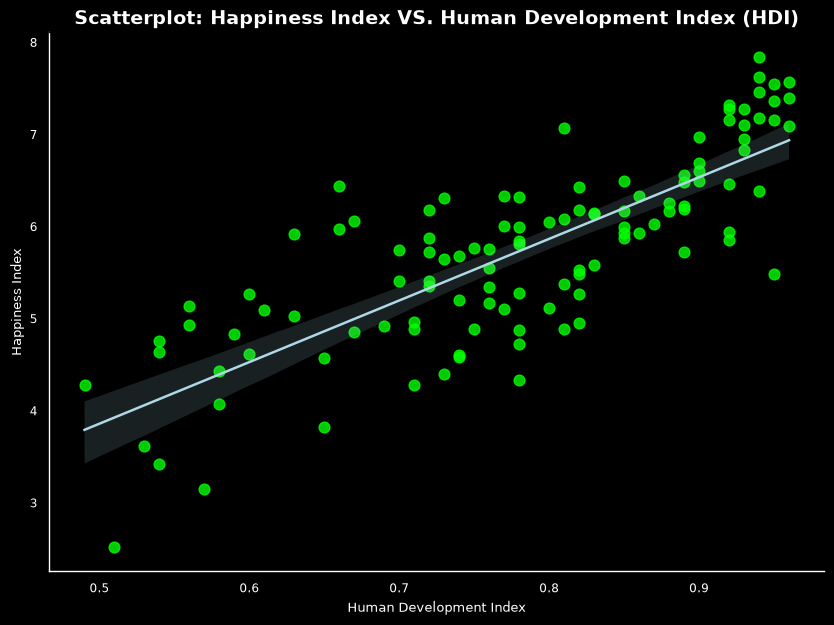

In [47]:
# Scatterplot
plt.figure(figsize=(10,7),facecolor="black")
plt.gca().set_facecolor("black")
sns.regplot(data = cr, x= "human_development_index", y="happiness_index", scatter_kws={"color":"lime", "s":60},
             line_kws={"color":"lightblue"} )
plt.title("Scatterplot: Happiness Index VS. Human Development Index (HDI)", color="white",fontweight="bold",fontsize=14)
plt.ylabel("Happiness Index",color="white")
plt.xlabel("Human Development Index", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

plt.gca().spines["left"].set_color("white")
plt.gca().spines["bottom"].set_color("white")

plt.show()


In [18]:
# Pearson correlation test
# HDI vs. Happiness Index

pear1 = cr[["human_development_index", "happiness_index"]]
r, p_value = pearsonr(pear1["human_development_index"], pear1["happiness_index"])

# Show results
print("r = ", r)
print("P-value = ", p_value)

r =  0.8001277545963265
P-value =  1.2888799350477625e-26


There is a strong positive correlation between HDI and Happiness Index (r = 0.80). Countries with higher Human Development Index values tend to have higher happiness scores. The relationship is statistically significant (p < 0.001), indicating that the observed correlation is extremely unlikely to have occurred by chance.

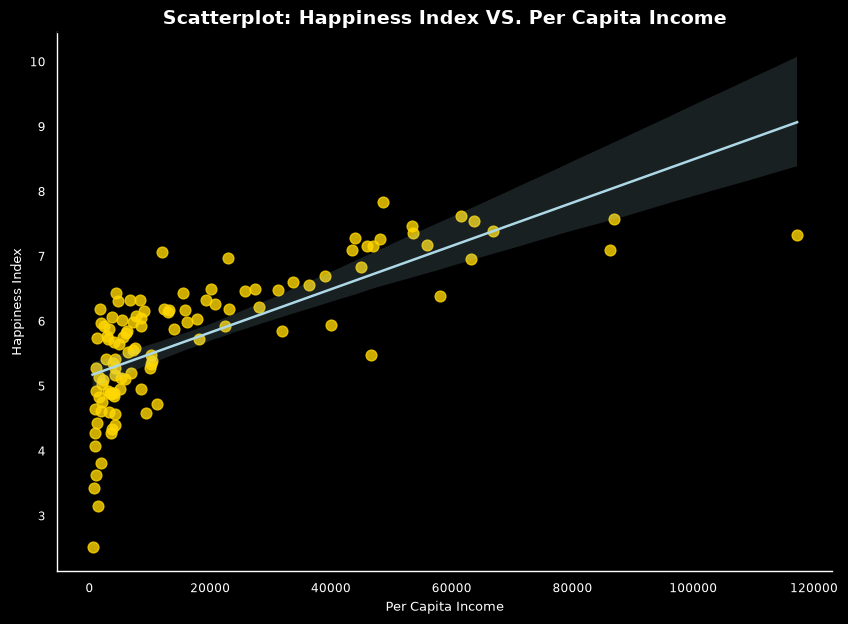

In [19]:
# Scatterplot
plt.figure(figsize=(10,7),facecolor="black")
plt.gca().set_facecolor("black")
sns.regplot(data = cr, x= "income", y="happiness_index", scatter_kws={"color":"gold", "s":60},
             line_kws={"color":"lightblue"} )
plt.title("Scatterplot: Happiness Index VS. Per Capita Income", color="white",fontweight="bold", fontsize=14)
plt.ylabel("Happiness Index",color="white")
plt.xlabel("Per Capita Income", color="white")

plt.xticks(color="white")
plt.yticks(color="white")

plt.gca().spines["left"].set_color("white")
plt.gca().spines["bottom"].set_color("white")

plt.show()


In [20]:
# Pearson correlation test
# Per Capita Income vs. Happiness Index

pear1 = cr[["income", "happiness_index"]]
r, p_value = pearsonr(pear1["income"], pear1["happiness_index"])

# Show results
print("r = ", r)
print("P-value = ", p_value)

r =  0.7190396582333471
P-value =  2.07133432071327e-19


#### Comment:

- The scatterplot and Pearson correlation analysis indicate a strong positive relationship between Per Capita Income and Happiness Index (r = 0.719, p < 0.001). Countries with higher per capita incomes tend to report higher levels of happiness. However, the dispersion of points around the regression line suggests that income alone does not determine happiness, and other social, economic, and developmental factors likely contribute to differences in happiness across countries.


- HDI appears to be a better predictor of happiness than income alone, suggesting that education, health, and overall human development contribute substantially to countries' well-being.

<hr></hr>

##  Multiple Linear Regression

In [21]:
# Fit linear regression
mlr_model = smf.ols("happiness_index ~ income + population_density + crime_rate + unemployment + human_development_index + literacy_rate + gini + weapons_per_100", data=cr ).fit()

print(mlr_model.summary())
print(mlr_model.conf_int())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     33.35
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           1.51e-25
Time:                        09:24:39   Log-Likelihood:                -92.004
No. Observations:                 114   AIC:                             202.0
Df Residuals:                     105   BIC:                             226.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

#### Comments:


- HDI is the primary driver of happiness. Holding other variables constant, a 0.1 increase in HDI increases predicted happiness by roughly 0.58 points.

- Higher income is associated with higher happiness.

- For every 1 percentage point increase in unemployment, happiness decreases by about 0.021 units.

- More densely populated areas tend to have slightly lower happiness after controlling for the other variables.

<br></br>

#### Breusch-Pagan 

The Breusch-Pagan test is used to determine whether the variance of the regression residuals is constant across observations (homoscedasticity) or changes with the predictors (heteroscedasticity).

Null Hypothesis (H0): The error variance is constant (homoscedasticity).

Alternative Hypothesis (H1): The error variance is not constant (heteroscedasticity).

In [ ]:
# Create Breuschpagan object
bp_test =  het_breuschpagan(mlr_model.resid, mlr_model.model.exog)

# create dataframe to return Breuch-Pagan statistics
bp_results = pd.DataFrame({
    'Statistics' : ['Linear Model Statistic', 'Linear Model P-Value', 'F Statistic', 'F Test P-value'],
    'Results': bp_test
})

print(bp_results)

               Statistics    Results
0  Linear Model Statistic  10.959506
1    Linear Model P-Value   0.204004
2             F Statistic   1.395990
3          F Test P-value   0.206773


#### Comment:
- There is insufficient evidence (p-value = 0.204) of heteroscedasticity in the model residuals. The assumption of constant error variance appears to be satisfied.
- Therefore, the null hypothesis of homoscedasticity could not be rejected, indicating that the residual variance appears to be constant across observations.

<br></br>

### Variance Inflation Factor (VIF) Analysis

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = cr[["income","population_density","crime_rate", "unemployment", "human_development_index", 
        "literacy_rate", "gini","weapons_per_100"]]


vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i)
            for i in range(X.shape[1])]
})

print(vif)

                  Variable       VIF
0                   income  2.735465
1       population_density  1.144963
2               crime_rate  1.623523
3             unemployment  1.172062
4  human_development_index  4.431968
5            literacy_rate  1.876628
6                     gini  1.444432
7          weapons_per_100  1.285712


<blockquote style="
    color: white;
    background-color: transparent;
    border-left: 4px double green;
    padding-left: 15px;
">
Most of the predictors don't have a multicollinearity problem. ALL VIF less than 5. A major concern would be if VIF > 10
</blockquote>

<br></br>

### Linear Model Diagnostics


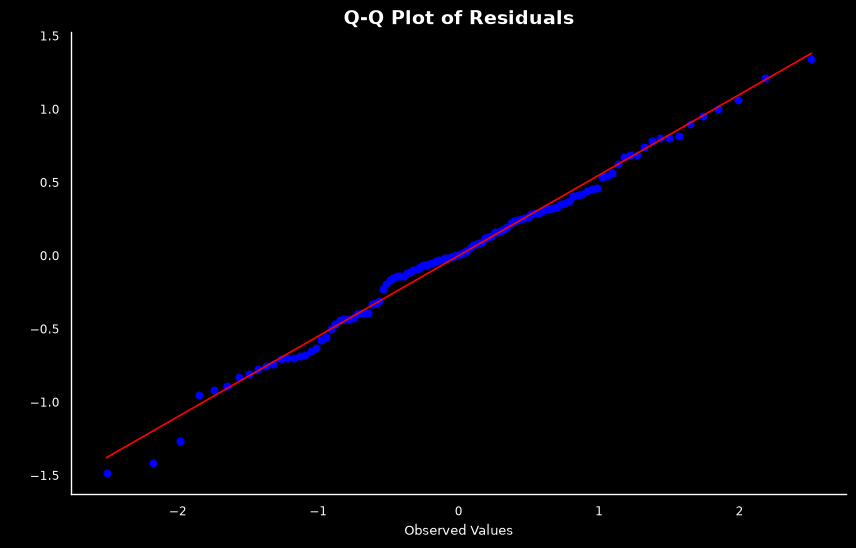

In [24]:
# Q-Q Plot
plt.figure(figsize=(10,6), facecolor="black")
plt.gca().set_facecolor("black")
stats.probplot(mlr_model.resid, dist="norm", plot=plt)

plt.title("Q-Q Plot of Residuals", fontweight="bold", color="white",fontsize=14)
plt.xlabel("Theoritical Quantiles", color="white")
plt.xlabel("Observed Values", color="white")


plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(color="white")
plt.yticks(color="white")

plt.gca().spines["left"].set_color("white")
plt.gca().spines["bottom"].set_color("white")

plt.show()

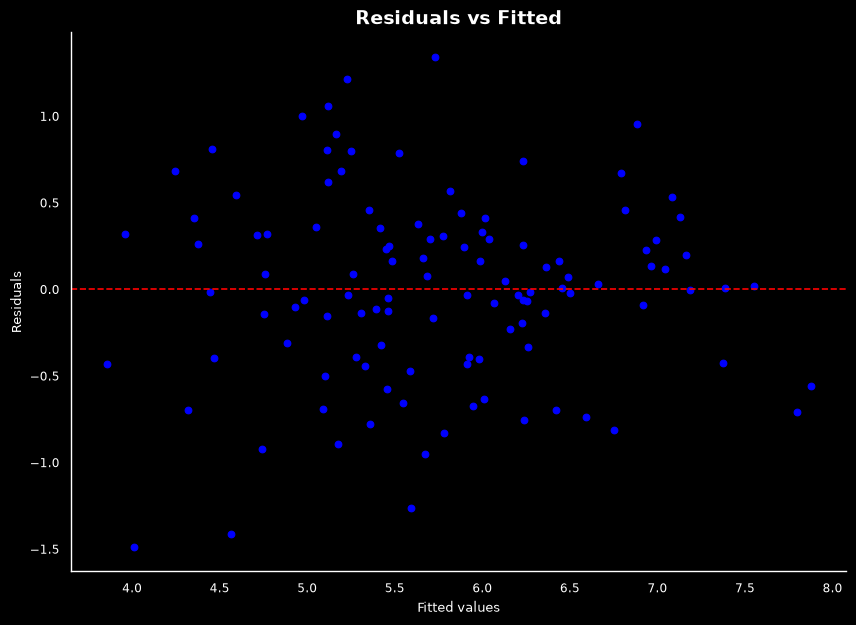

In [25]:

# Residual vs fitted values
plt.figure(figsize=(10,7),facecolor="black")
plt.gca().set_facecolor("black")

plt.scatter(mlr_model.fittedvalues, mlr_model.resid, color="blue")
plt.axhline(0, linestyle="--", color="red")
plt.xlabel("Fitted values", color="white")
plt.ylabel("Residuals",color="white")
plt.title("Residuals vs Fitted", fontweight="bold", color="white", fontsize=14)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.xticks(color="white")
plt.yticks(color="white")

plt.gca().spines["left"].set_color("white")
plt.gca().spines["bottom"].set_color("white")
plt.show()

#### Diagnostic comment:
- The residuals are scattered around the red horizontal line at 0 rather than forming a curve.

- The residuals appear distributed both above and below the zero line throughout the entire range of fitted values.

- The Residuals vs. Fitted Values plot indicates that **the assumptions of linearity and constant variance are satisfied.**
- The spread of residuals remains relatively consistent across fitted values, suggesting that **heteroscedasticity is not a major concern.** 

<br></br>

## Influence Analysis

In [26]:
# influence diagnostics help identify observations that may have
#  an unusually large impact the regression model.
influence = mlr_model.get_influence()
summary_frame = influence.summary_frame()

print("Summary Frame:")
print("=========================================")
print(summary_frame[["standard_resid", "hat_diag", "cooks_d"]
                    ].sort_values("cooks_d", ascending=False).head(10)) 

Summary Frame:
     standard_resid  hat_diag   cooks_d
91         1.606146  0.609960  0.448249
40        -1.857175  0.481393  0.355733
0         -2.955047  0.206055  0.251813
107       -1.121782  0.553689  0.173461
60        -1.202284  0.328050  0.078411
21         2.496239  0.094898  0.072592
64         1.548682  0.161613  0.051371
113       -2.583320  0.060784  0.047989
47        -1.371389  0.163474  0.040836
38         2.202949  0.047356  0.026804


In [27]:
# Identify most influencial observations
cr.loc[[91, 40, 0, 107]]

,Country,crime_rate,unemployment,human_development_index,population_density,weapons_per_100,income,gini,literacy_rate,happiness_index
91,Singapore,27.96,3.6,0.94,8041.0,0.3,58114.0,0.36,0.97,6.38
40,Hong Kong,22.00,6.4,0.95,6677.0,3.6,46611.0,46.70,0.99,5.48
0,Afghanistan,76.31,11.2,0.51,57.0,12.5,508.0,27.80,0.38,2.52
107,United States,47.81,3.8,0.93,34.0,120.5,63123.0,34.80,0.86,6.95


<br></br>

## Model Refinement

In [ ]:
# Transform income to log income
# Reason: Happiness increases with income, but at a decreasing rate, reflecting the principle of diminishing marginal returns.
cr["log_income"] = np.log1p(cr["income"])

In [29]:
# Fit new model without non-significant variables
mlr_model2 = smf.ols("happiness_index ~ log_income + population_density + unemployment + human_development_index ", data=cr ).fit()

print(mlr_model2.summary())
print(mlr_model2.conf_int())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.704
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     64.89
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           5.76e-28
Time:                        09:24:39   Log-Likelihood:                -94.632
No. Observations:                 114   AIC:                             199.3
Df Residuals:                     109   BIC:                             212.9
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 


-  It appears that happiness is explained largely by income, population density, and labor market conditions, with HDI providing limited additional predictive value once income is modeled on a logarithmic scale.

In [30]:
# Fit third model
mlr_model3 = smf.ols("happiness_index ~ log_income + population_density + unemployment ", data=cr ).fit()

print(mlr_model3.summary())
print(mlr_model3.conf_int())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.699
Model:                            OLS   Adj. R-squared:                  0.690
Method:                 Least Squares   F-statistic:                     85.02
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           1.57e-28
Time:                        09:24:39   Log-Likelihood:                -95.694
No. Observations:                 114   AIC:                             199.4
Df Residuals:                     110   BIC:                             210.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.1699      0

In [31]:
# Fit fourth model
mlr_model4 = smf.ols("happiness_index ~ log_income + population_density ", data=cr ).fit()

print(mlr_model4.summary())
print(mlr_model4.conf_int())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.687
Method:                 Least Squares   F-statistic:                     125.3
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           3.42e-29
Time:                        09:24:39   Log-Likelihood:                -96.755
No. Observations:                 114   AIC:                             199.5
Df Residuals:                     111   BIC:                             207.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.3050      0

- The final analysis indicates that happiness is strongly associated with income, particularly when income is in logarithmic form, suggesting diminishing marginal returns to income.
-  Population density exhibits a statistically significant negative relationship with happiness, while unemployment shows a negative but statistically insignificant effect after controlling for income and density. 
-  Diagnostic testing found no evidence of major violations of OLS assumptions, including heteroscedasticity, non-normal residuals, multicollinearity, or excessively influential observations. 
-  The results appear robust and suggest that economic prosperity remains the strongest predictor of happiness in the sample.

### Refinement with Interaction Terms

In [39]:
# Center variables to avoid multicolinearity
cr['c_log_income'] = (cr['log_income'] - cr['log_income'].mean())

cr['c_hdi'] = (cr['human_development_index']- cr['human_development_index'].mean())

cr['c_density'] = (cr['population_density']- cr['population_density'].mean())

cr['c_unemployment'] = ( cr['unemployment'] - cr['unemployment'].mean())

Does income have a stronger effect on happiness in high-HDI countries than low-HDI countries?

In [ ]:
# Income and hdi interaction
cr['income_hdi'] = cr['c_log_income'] * cr['c_hdi']

# create model with interaction
i_mod1 = smf.ols("happiness_index ~ log_income + population_density + human_development_index + income_hdi", data = cr).fit()

print(i_mod1.summary())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.697
Model:                            OLS   Adj. R-squared:                  0.686
Method:                 Least Squares   F-statistic:                     62.73
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           2.08e-27
Time:                        10:50:02   Log-Likelihood:                -95.983
No. Observations:                 114   AIC:                             202.0
Df Residuals:                     109   BIC:                             215.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

Does unemployment hurt happiness more in low-income countries?

In [ ]:
# Interaction term
cr['income_unemployment'] = cr['c_log_income'] * cr['c_unemployment']

# model with interaction term
i_mod2 = smf.ols("happiness_index ~ log_income + population_density + unemployment + income_unemployment", data = cr).fit()

print(i_mod2.summary())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.719
Model:                            OLS   Adj. R-squared:                  0.709
Method:                 Least Squares   F-statistic:                     69.81
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           3.46e-29
Time:                        10:50:07   Log-Likelihood:                -91.668
No. Observations:                 114   AIC:                             193.3
Df Residuals:                     109   BIC:                             207.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              -0.7014    

Are dense cities less detrimental when a country is wealthy?

In [ ]:
# Create population density and income interaction
cr['dense_income'] = cr['c_log_income'] * cr['c_density']

# model with interaction term
i_mod3 = smf.ols("happiness_index ~ log_income + population_density + dense_income", data = cr).fit()

print(i_mod3.summary())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.685
Method:                 Least Squares   F-statistic:                     82.95
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           4.02e-28
Time:                        10:50:13   Log-Likelihood:                -96.673
No. Observations:                 114   AIC:                             201.3
Df Residuals:                     110   BIC:                             212.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.3383      0

Does unemployment hurt happiness less in highly developed countries because of stronger social safety nets?

In [ ]:
# Create hdi and unemployment interaction
cr['hdi_unemployment'] = cr['c_hdi'] * cr['c_unemployment']

# model with interaction term
i_mod4 = smf.ols("happiness_index ~ log_income + population_density + unemployment + human_development_index + hdi_unemployment", data = cr).fit()

print(i_mod4.summary())

                            OLS Regression Results                            
Dep. Variable:        happiness_index   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.712
Method:                 Least Squares   F-statistic:                     56.90
Date:                Sun, 04 Oct 2026   Prob (F-statistic):           1.05e-28
Time:                        10:50:22   Log-Likelihood:                -90.519
No. Observations:                 114   AIC:                             193.0
Df Residuals:                     108   BIC:                             209.5
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [44]:
# Crwate quantile group for human development index
cr['hdi_group'] = pd.qcut(cr['human_development_index'],q=3,labels=['Low HDI', 'Medium HDI', 'High HDI'])


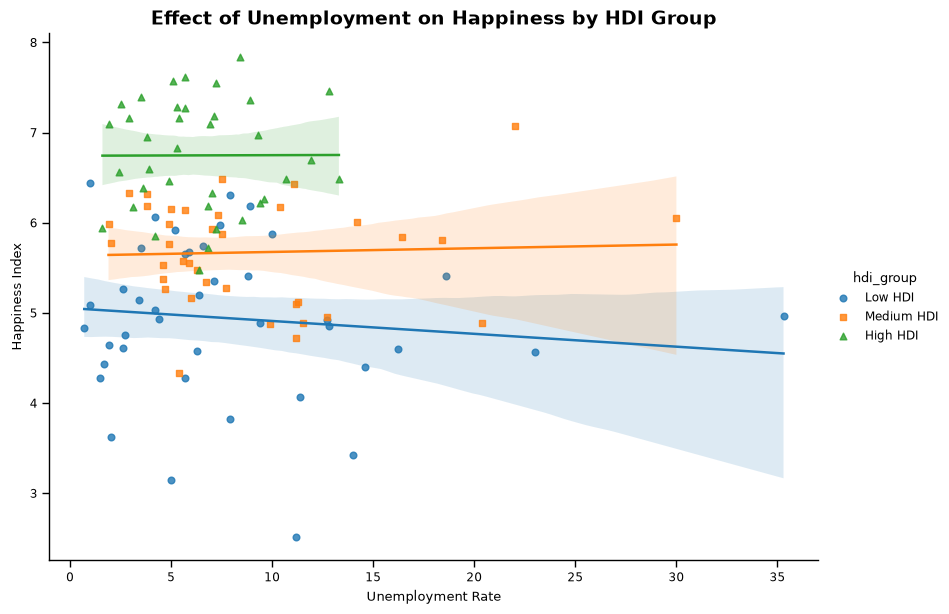

In [45]:
# Plot interaction
sns.lmplot(data=cr, x='unemployment',y='happiness_index',hue='hdi_group',height=6,aspect=1.4,markers=['o', 's', '^'])

plt.title('Effect of Unemployment on Happiness by HDI Group', fontweight="bold", fontsize=14)
plt.xlabel('Unemployment Rate')
plt.ylabel('Happiness Index')
plt.show()

Happiness is strongly associated with income and population density, but the relationship between unemployment and happiness is moderated by human development. Countries with higher levels of human development appear better able to mitigate the adverse effects of unemployment on well-being.